In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.basemap import Basemap as Basemap 
#import community.community_louvain as community_louvain
import numpy as np
import os
import community.community_louvain as community_louvain
#import graph_tool.all as gt
#import graph_draw
import graph_tool as gt
#import graph_tool.inference as gti
#from graph_tool.inference import minimize_blockmodel_dl, BlockState
#import graph_tool.all as gt
#from mpl_toolkits.basemap import Basemap as Basemap
import csv
#from utilsss import write_dict_to_csv
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path
from network_analysis import *

In this file we create the network in networkx and graph_tool, we considere 3 types of networks (coordinator, participant, coordinator + participant)
We consider also the network only of the EFTA countries and the one where all the European countries are in one unique node
We compute some measures (mostly on the coord + part network):
- gini index (number of projects or collaborations per country or per capita per country)
- in/out/total strength and their maps (Europe/world)
- strength, closeness, betweenness, eigenvector centralities
- density, clustering coefficient
- similarity between networks communities (BCubed)
- plot integration / segregation (computed in R file int_segr_agation)

In [ ]:
# set directory
cwd = Path.cwd()
parent_dir = cwd.parent

# data dir
data_dir = parent_dir / 'Data'

# networks dir
network_edgelist_dir = parent_dir / 'Networks EFTA countries'

# analysis dir
analysis_dir = 'analysis'

## Functions

In [3]:
def write_dict_to_csv(dictionary, filename, columns):
    '''Write from dictionary to csv'''
    
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(columns)
        for key, value in dictionary.items():
            writer.writerow([key, value])



def write_dict_to_df(dictionary, columns):
    '''From dictionary to dataframe'''

    df = pd.DataFrame(columns=columns)
    for key, value in dictionary.items():
        df = df._append({columns[0]: key, columns[1]: value}, ignore_index=True)

    return df



# NB: VERIFIED THAT FUNCTIONS gini_index AND gini RETURN EQUIVALENT RESULTS

def gini_index(distribution):
    '''Compute gini index of a distribution'''

    # Ensure the distribution is a numpy array
    distribution = np.array(distribution)
    
    # Number of elements
    n = len(distribution)
    
    # Mean of the distribution
    mean = np.mean(distribution)
    #print('mean', mean)
    
    # Gini calculation
    gini_sum = 0
    for i in range(n):
        for j in range(n):
            gini_sum += np.abs(distribution[i] - distribution[j])
    
    gini_index = gini_sum / (2 * n**2 * mean)

    return gini_index


def gini(series_of_values):
    '''Compute gini index of a distribution'''
    
    sorted_list = sorted(series_of_values.fillna(0))
    height, area = 0, 0
    for value in sorted_list:
        height += value
        area += height - value / 2.
    fair_area = height * len(sorted_list) / 2.
    if fair_area == 0:
        return np.nan
    return (fair_area - area) / fair_area




# functions to compute F1 for similarity between communities in different networks (partitions) -> BCubed paper -> https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0256175

def jaccard(set1, set2):
    '''Compute jaccard index between two sets'''

    jaccard = len(set1.intersection(set2)) / len(set1.union(set2))

    return jaccard


def f1_similarity_diff(set1, set2):
    '''
    Compute F1 similarity when we have some overlapping and some non-overlapping nodes in the two partitions -> max F1
    set1, set2 : sets of nodes resectively in the first and second partitions
    '''

    jac = jaccard(set1, set2)
    f1 = (2 * jac) / (1 + jac)

    return f1


def precision_n(l_community, c_community):
    '''
    Compute precision for node n
    l_community : 'ground truth' community (first one) node n belongs to
    c_community : detected community of node n (second one) node n belongs to
    '''

    return len(l_community.intersection(c_community)) / len(c_community)


def recall_n(l_community, c_community):
    '''
    Compute precision for node n
    l_community : 'ground truth' community (first one) node n belongs to
    c_community : detected community of node n (second one) node n belongs to
    '''

    return len(l_community.intersection(c_community)) / len(l_community)


def search_el(el, list_of_sets):
    '''
    Given an element and a list of sets, find the set where this element falls into
    '''
    
    found = False
    num_set = 0
    res = []

    while (found == False) and (num_set < len(list_of_sets)):
        #print(el)
        #print(list_of_sets[num_set])
        if el in list_of_sets[num_set]:
            found = True
            res = list_of_sets[num_set]
        else:
            num_set += 1
    
    return res
    

def precision_recall_c_l(c, l):
    '''
    Compute precision and recall for the core-F1, where pair of network partitions consist of same set of nodes
    '''
    
    sum_precision = 0
    sum_recall = 0

    len_c = 0
    len_l = 0

    for set in c:
        len_c += len(set)
    for set in l:
        len_l += len(set)

    for set_c in c:
        #print('set', set_c)
        for el in set_c:
            set_l = search_el(el, l)
            sum_precision += precision_n(set_l, set_c)
            sum_recall += recall_n(set_l, set_c)
    
    precision = 1 * sum_precision / len_c
    recall = 1 * sum_recall / len_l

    return precision, recall


def f1_similarity_eq(c, l):
    '''
    Compute core-F1, where pair of network partitions consist of same set of nodes
    '''
    
    precision, recall = precision_recall_c_l(c, l)
    f1 = (2*precision*recall) / (precision+recall)

    return f1


# TODO not sure about how they develop it in the paper
'''def f1_similarity_standard(net0, net1, communities_0, communities_1):
    
    Compute standard-F1, where partitions have some overlapping nodes and others specific to the respective partitions
    

    nodes0 = net0.difference(net1) # R0
    nodes1 = net1.difference(net0) # R1

    # overlapping communities (nodes) -> equal for both
    nodes_c = net0.intersection(net1)
    nodes_l = net0.intersection(net1)'''
    
    



'def f1_similarity_standard(net0, net1, communities_0, communities_1):\n    \n    Compute standard-F1, where partitions have some overlapping nodes and others specific to the respective partitions\n    \n\n    nodes0 = net0.difference(net1) # R0\n    nodes1 = net1.difference(net0) # R1\n\n    # overlapping communities (nodes) -> equal for both\n    nodes_c = net0.intersection(net1)\n    nodes_l = net0.intersection(net1)'

## Read files

In [4]:
org_dir = data_dir / 'organizations/'
network_dir = network_edgelist_dir / 'nx graph' / 'without self-loops'

In [5]:
# read data

# organizations
org_list = []
for i in range(1, 10):
    org_file = 'org_' + str(i) + '_updated.csv'
    org = pd.read_csv(org_dir / org_file)
    org_list += [org]

# efta countries
efta_countries = list(pd.read_csv(data_dir / 'efta countries.csv')['country'].map(lambda x: x.lower()))

/tmp/ipykernel_2014224/1420359680.py:7: DtypeWarning: Columns (3,8,13,19) have mixed types. Specify dtype option on import or set low_memory=False.
  org = pd.read_csv(org_dir / org_file)
/tmp/ipykernel_2014224/1420359680.py:7: DtypeWarning: Columns (3,8,13,19) have mixed types. Specify dtype option on import or set low_memory=False.
  org = pd.read_csv(org_dir / org_file)
/tmp/ipykernel_2014224/1420359680.py:7: DtypeWarning: Columns (3,13) have mixed types. Specify dtype option on import or set low_memory=False.
  org = pd.read_csv(org_dir / org_file)
/tmp/ipykernel_2014224/1420359680.py:7: DtypeWarning: Columns (18,19,21,23) have mixed types. Specify dtype option on import or set low_memory=False.
  org = pd.read_csv(org_dir / org_file)
/tmp/ipykernel_2014224/1420359680.py:7: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  org = pd.read_csv(org_dir / org_file)
/tmp/ipykernel_2014224/1420359680.py:7: DtypeWarning: Columns (19,20,2

## Projects per Framework Programme per country

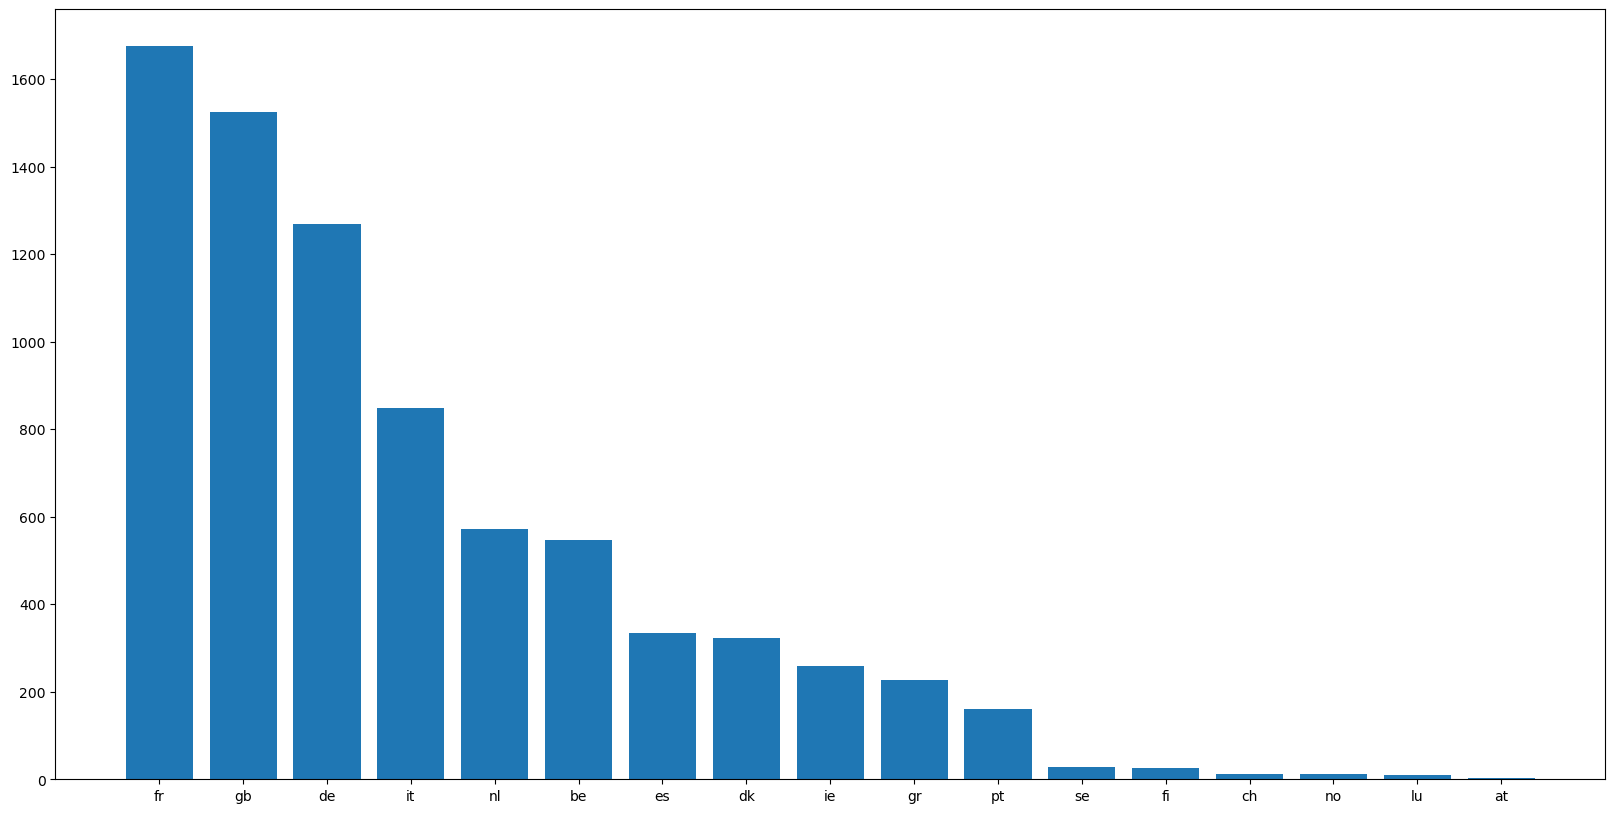

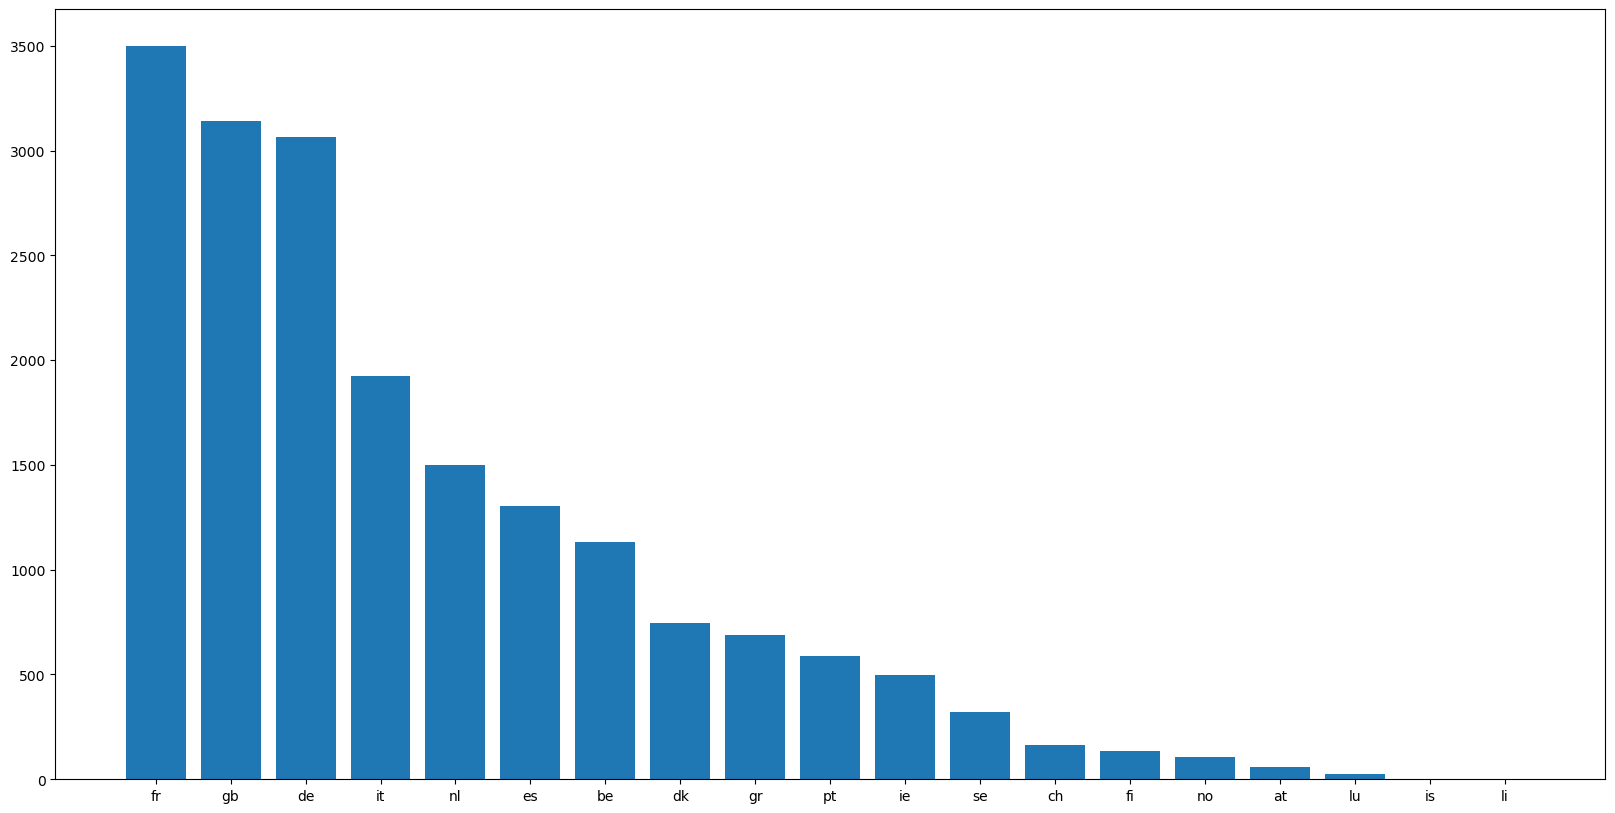

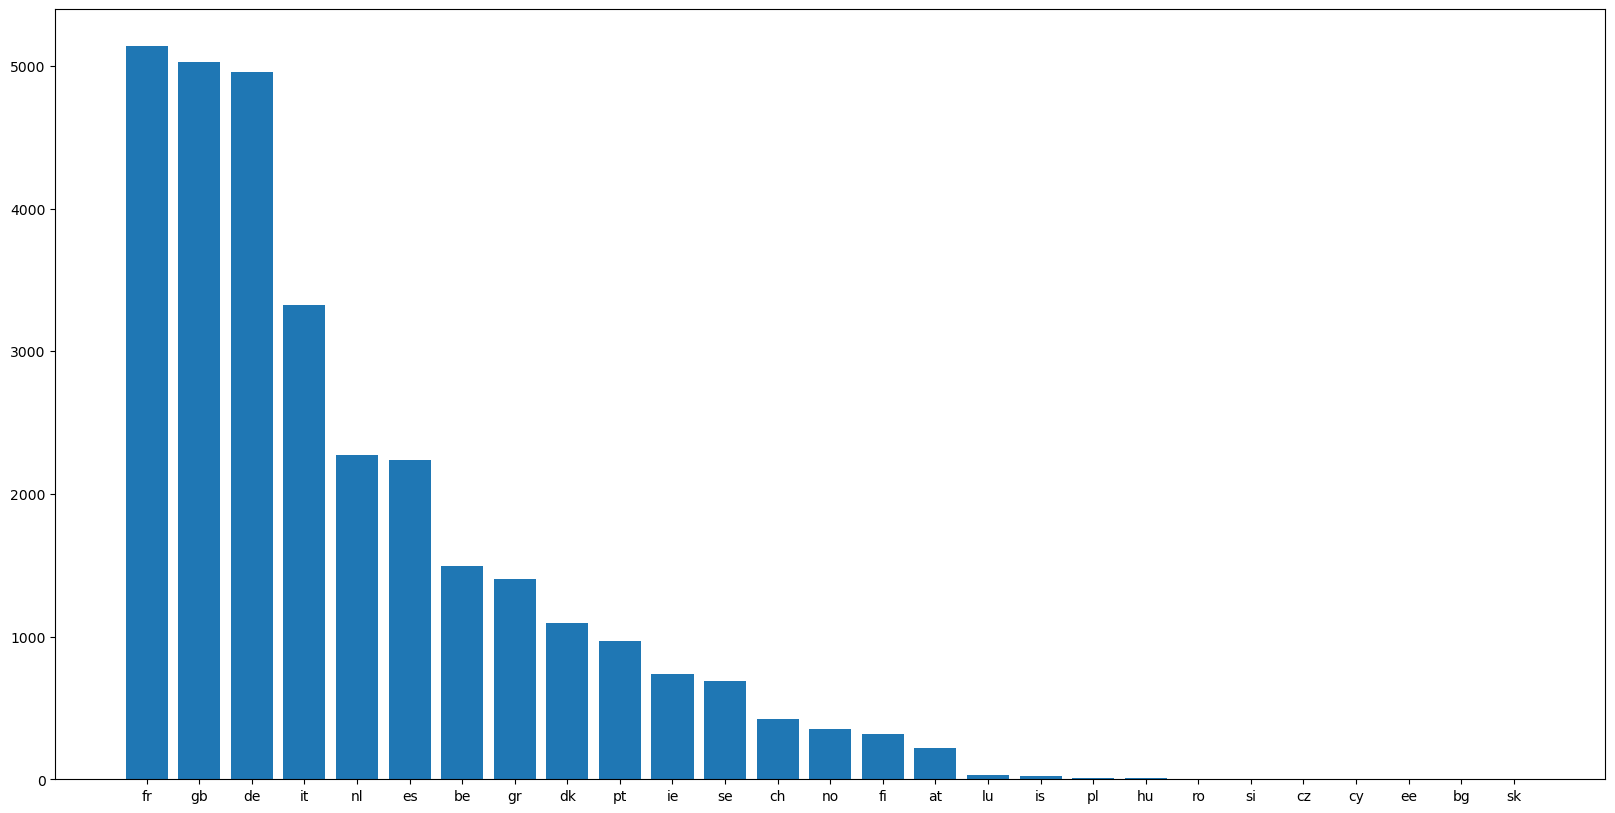

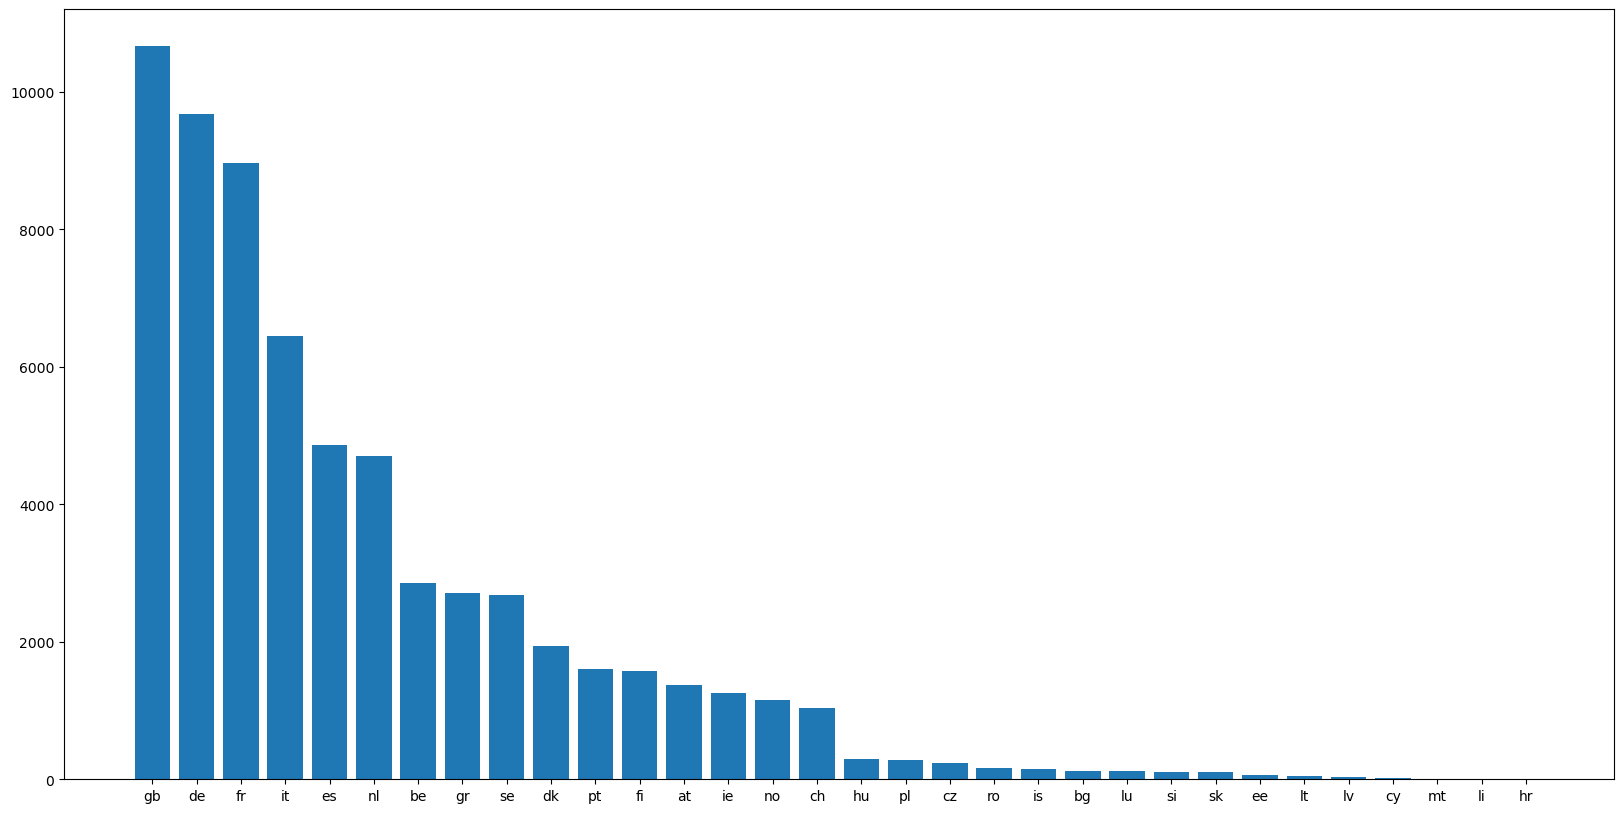

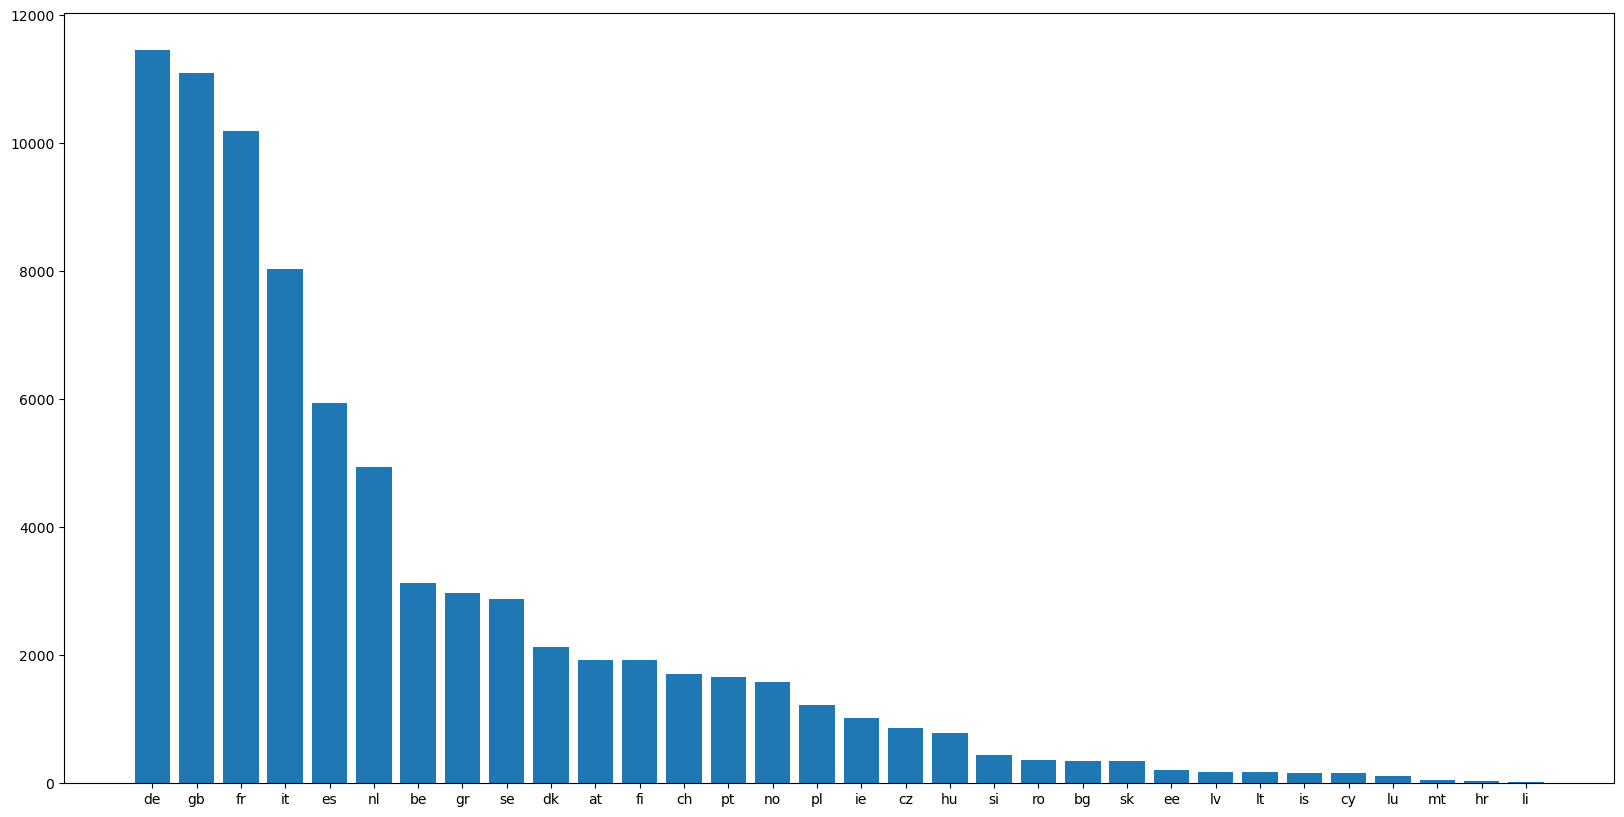

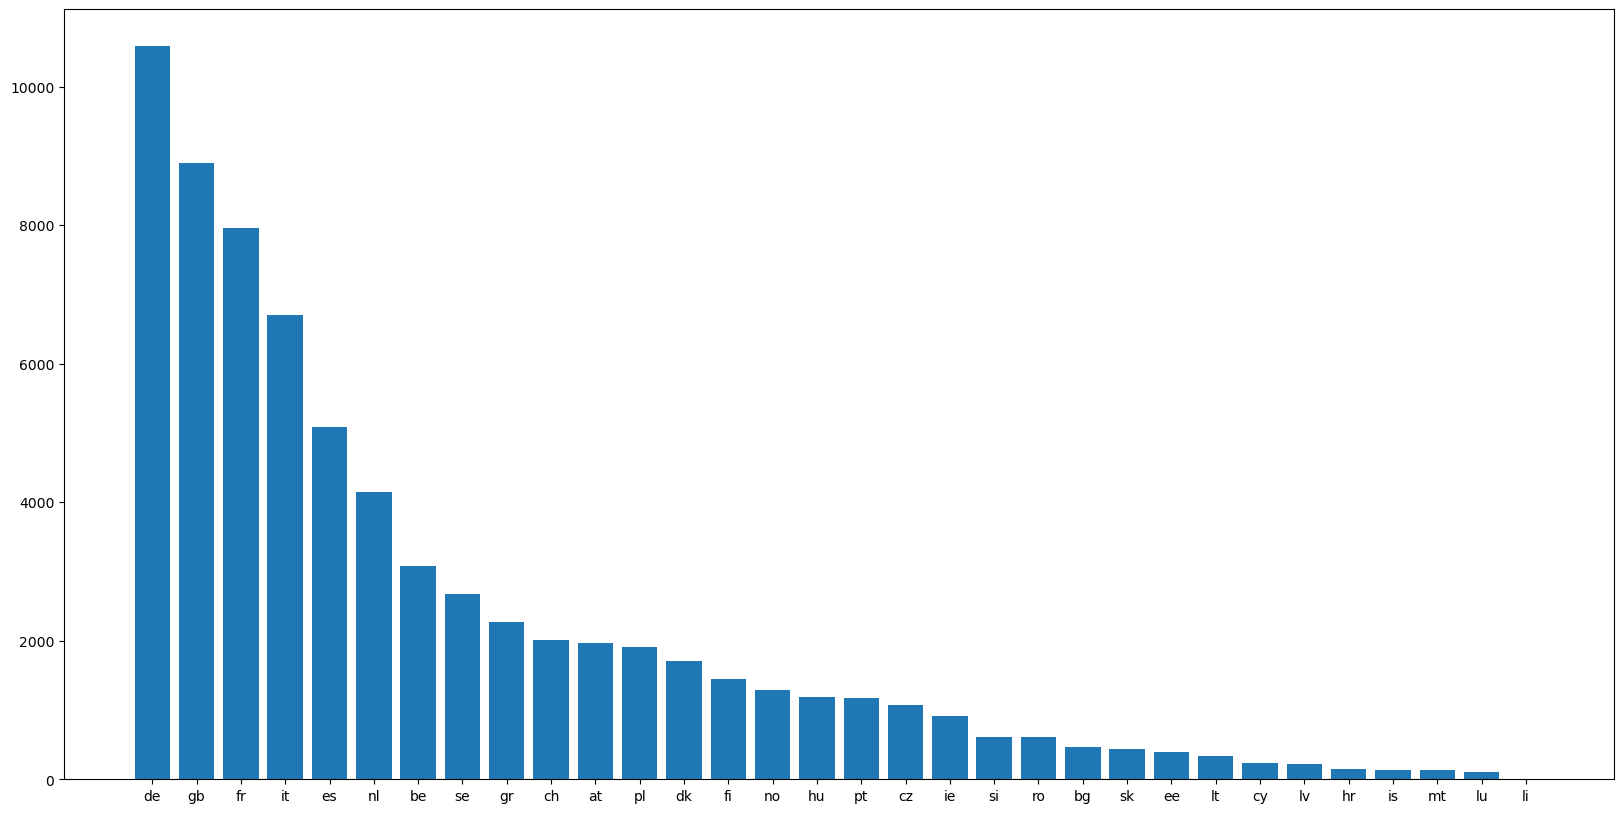

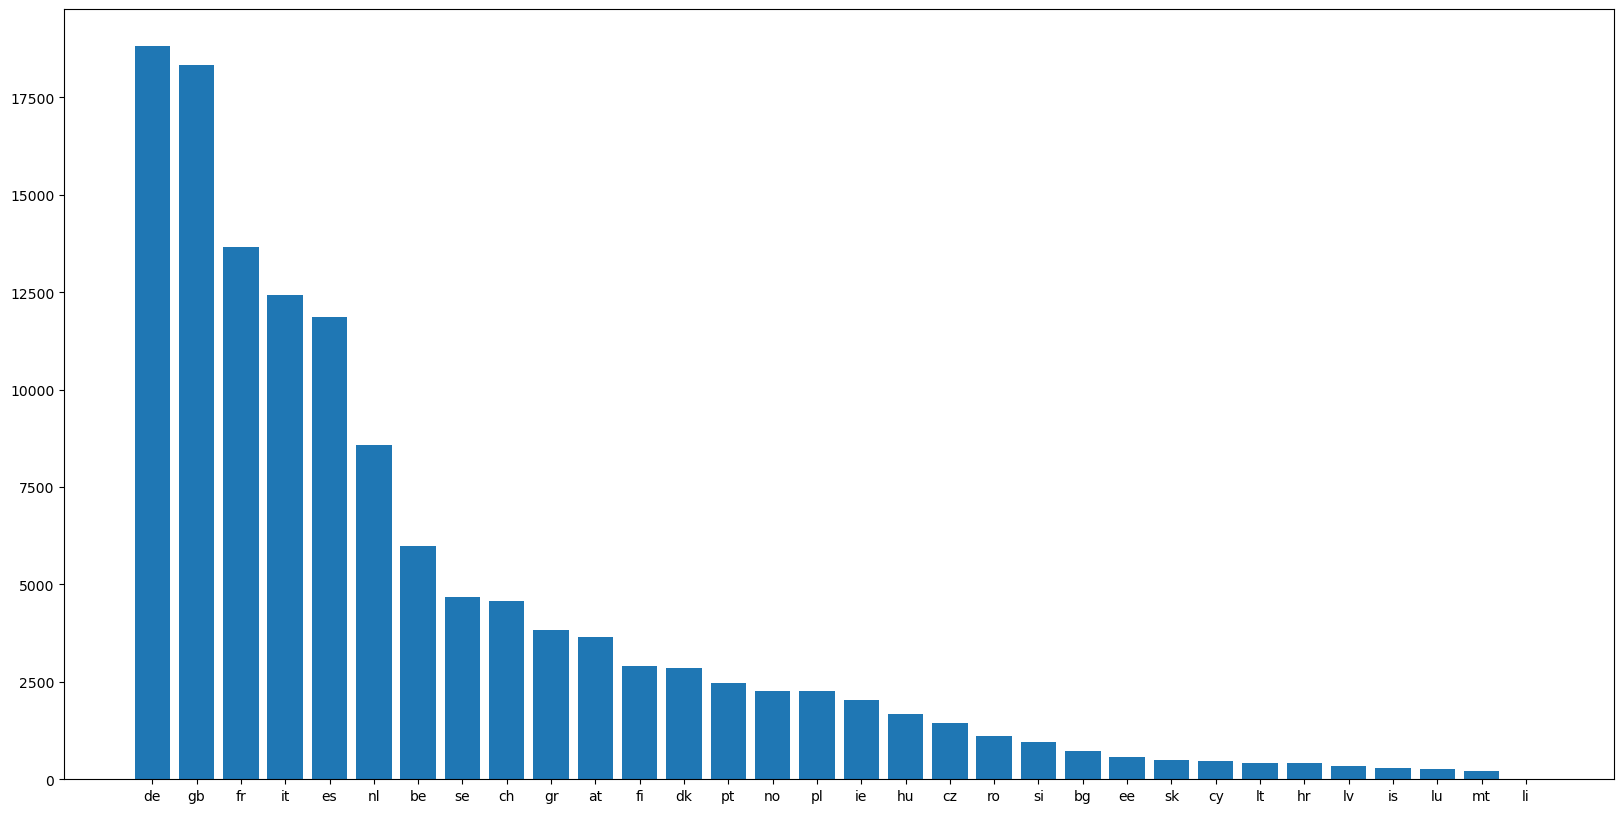

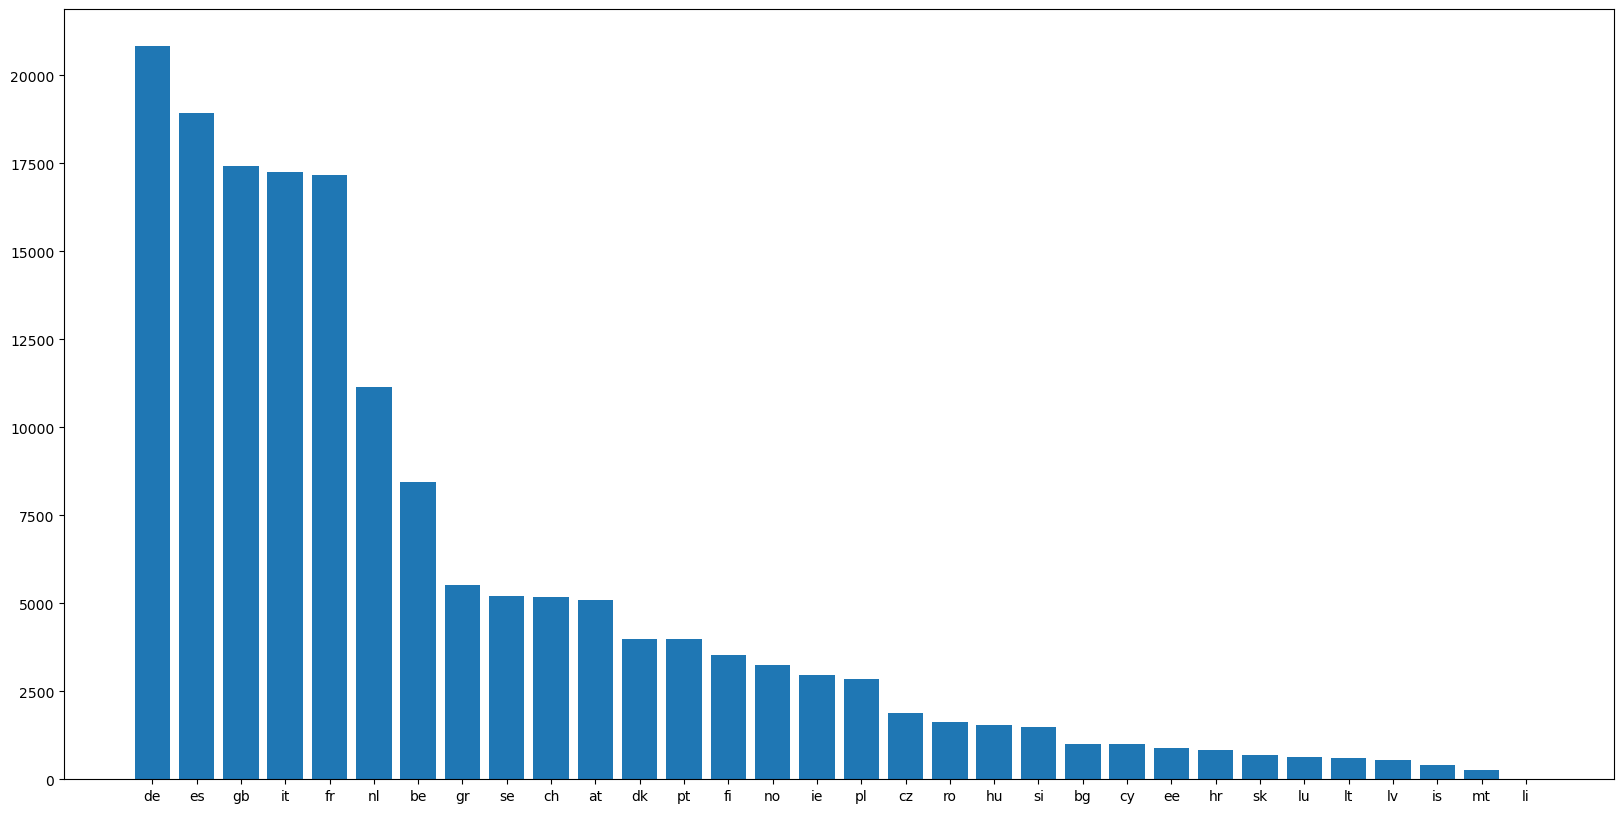

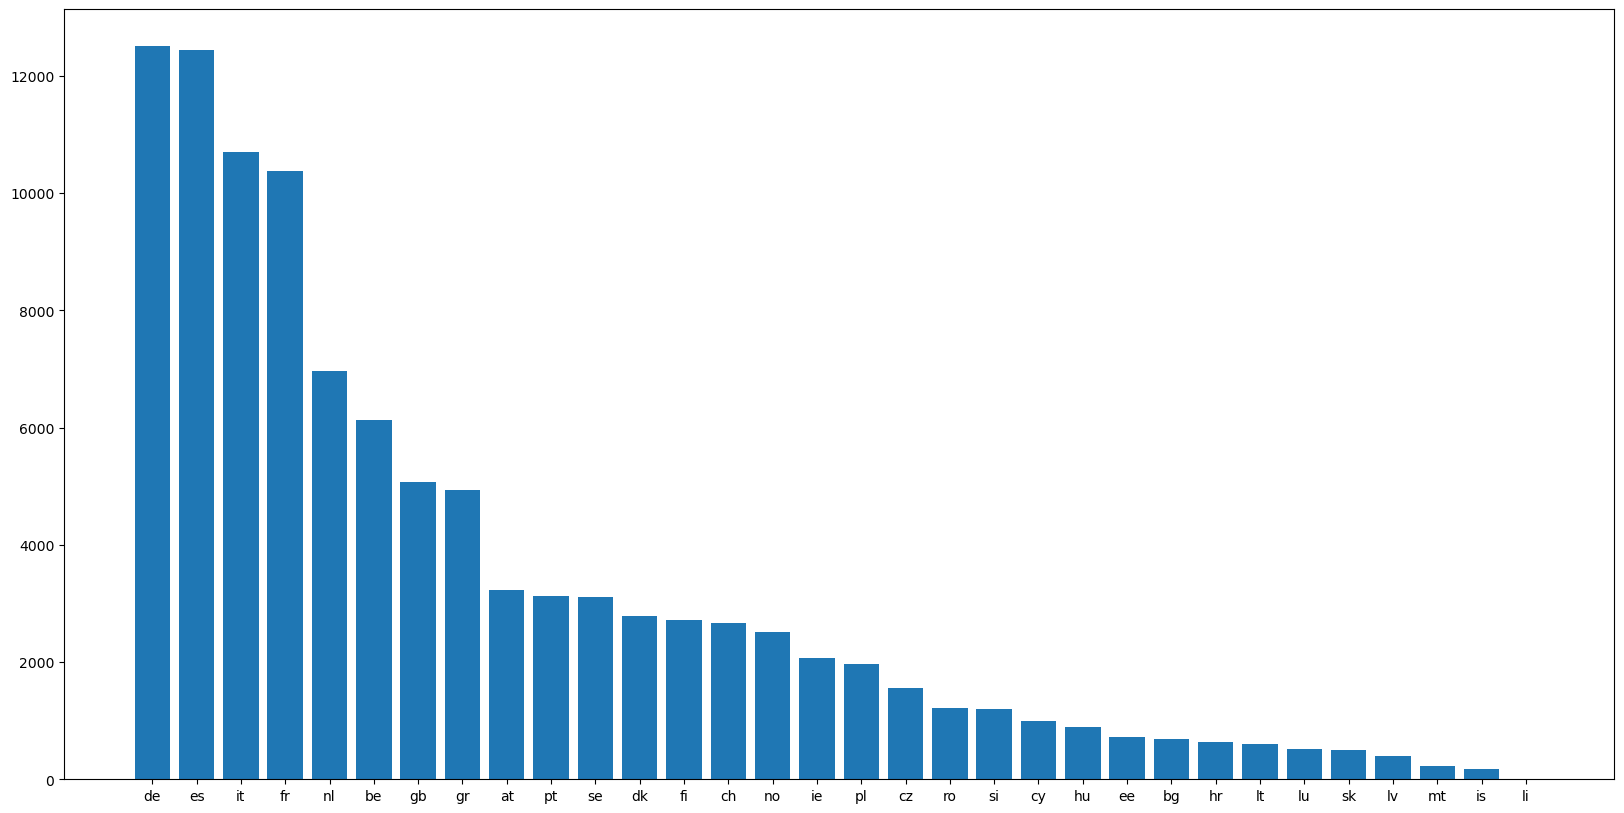

[7831, 18894, 30755, 65315, 78119, 69956, 130604, 166287, 103640]


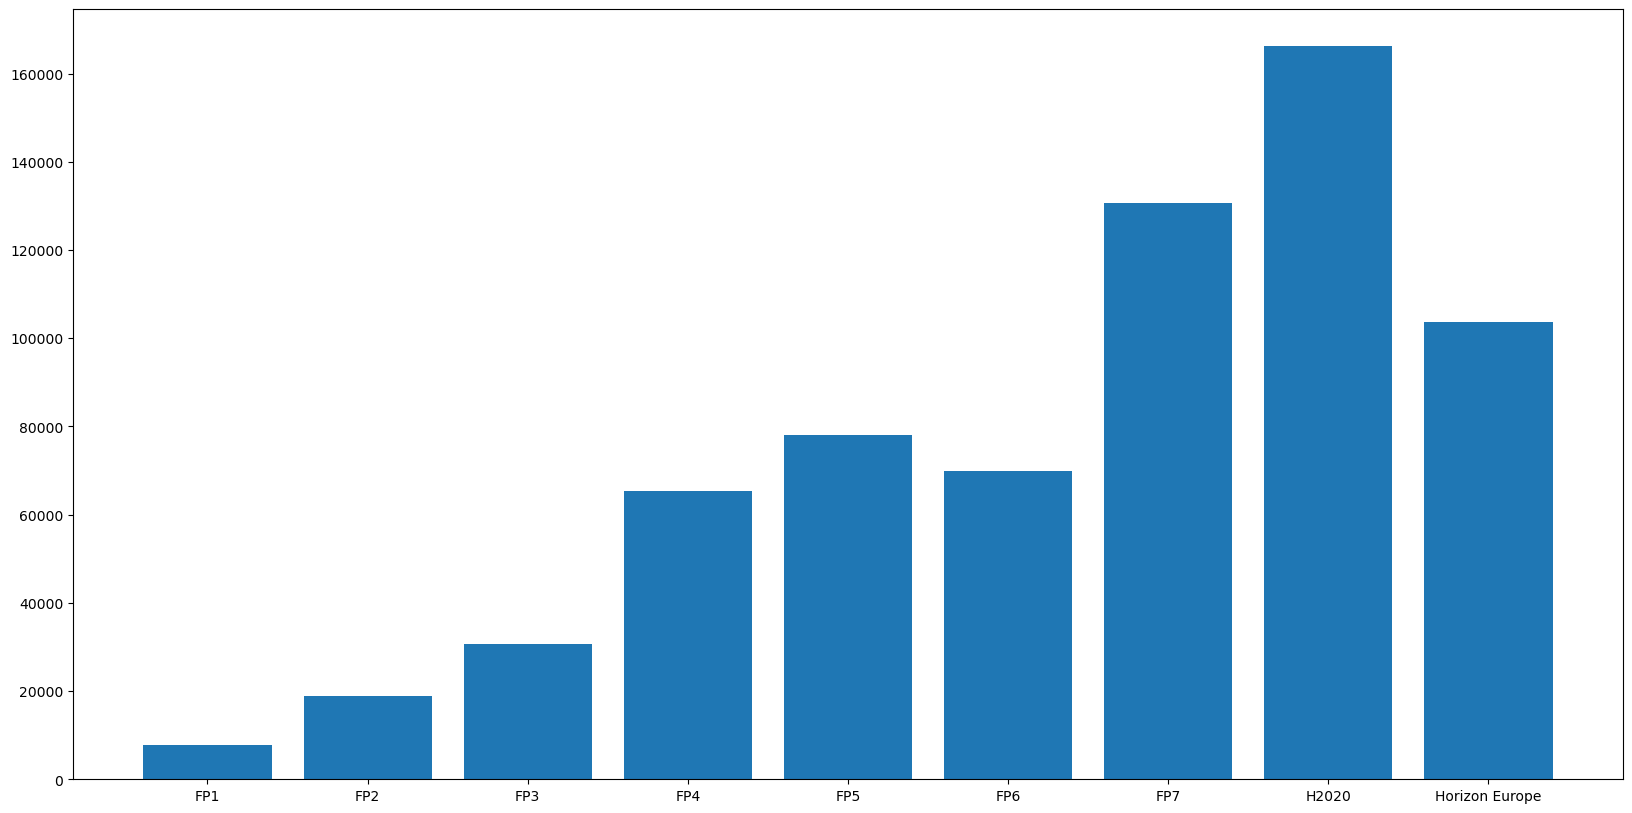

In [18]:
# read proj per country

dir_proj_country = analysis_dir / 'proj_per_country/'

output_dir = dir_proj_country / 'plots'

proj_num_list = []

fp_list = ['FP1', 'FP2', 'FP3', 'FP4', 'FP5', 'FP6', 'FP7', 'H2020', 'Horizon Europe']

# read efta countries
efta_df = pd.read_csv(data_dir / 'efta countries.csv')
efta_countries = list(efta_df['country'].str.lower())

for i in range(1, 10):
    proj_country_file = 'proj_country_' + str(i) + '.csv'
    proj_country_df = pd.read_csv(dir_proj_country / proj_country_file)
    proj_country_df = proj_country_df[proj_country_df['country'].isin(efta_countries)]
    num_proj = proj_country_df['count_proj'].sum()
    proj_num_list += [num_proj]

    fig, ax = plt.subplots(figsize=(20, 10))
    ax.bar(proj_country_df['country'], proj_country_df['count_proj'])
    plt.show()
    output_file = str(i) + '_by_country.png'
    #fig.savefig(output_dir / output_file)

print(proj_num_list)
fig, ax = plt.subplots(figsize=(20, 10))
ax.bar(fp_list, proj_num_list)
#fig.savefig(output_dir / 'FP_tot.png')
plt.show()

## Degree centrality

In [ ]:
# compute degree centrality

output_dir = analysis_dir / 'degree no self-loops'

# networks
for i in range(1, 10):
    network_file = 'network_' + str(i) + '.graphml'
    network = nx.read_graphml(network_dir / network_file)
    output_file = 'degree_' + str(i) + '.csv'
    #network_degree(network, 'country', output_dir / output_file)

## Gini index

### Set variables

In [8]:
# drop duplicates of (projectRcn, name) -> avoid errors where the same organization is assigned to the same project more than once
# groupby country -> count number of projects assigned to each country

# output dir for projects per country
proj_per_country_dir = analysis_dir / 'proj_per_country'

# set variables
org_list_grouped = []
country_col = 'country_code_ok'

# aggregate by country and count projects per country
for i in range(9):
    proj_country = org_list[i].groupby(by=country_col).agg(country=pd.NamedAgg(column=country_col, aggfunc='first'), count_proj=pd.NamedAgg(column=country_col, aggfunc='count')).reset_index(drop=True).sort_values(by='count_proj', ascending=False)
    org_list_grouped += [proj_country]
    
    proj_country_file = 'proj_country_' + str(i+1) + '.csv'
    #proj_country.to_csv(proj_per_country_dir / proj_country_file)

# take subset of efta countries of previous fp in each fp
df_1 = pd.read_csv(analysis_dir / 'degree no self-loops' / 'degree_1.csv')
df_2 = pd.read_csv(analysis_dir / 'degree no self-loops' / 'degree_2.csv')
df_3 = pd.read_csv(analysis_dir / 'degree no self-loops' / 'degree_3.csv')
df_4 = pd.read_csv(analysis_dir / 'degree no self-loops' / 'degree_4.csv')
countries_1 = list(df_1['country'])
countries_2 = list(df_2['country'])
countries_3 = list(df_3['country'])
countries_4 = list(df_4['country'])
list_df = [countries_1, countries_2, countries_3, countries_4, countries_4, countries_4, countries_4, countries_4, countries_4]

# extract subset of nodes of fp1, fp2, fp3 from fp2, fp3, fp4, fp5, fp6, fp7, h2020, horizon europe
org_list_grouped_subset = []
for i in range(0, 9):
    for y in range(i, 9):
        df = org_list[y]
        sub_df = df[df['country_code_ok'].isin(list_df[i])]
        proj_country = sub_df.groupby(by=country_col).agg(country=pd.NamedAgg(column=country_col, aggfunc='first'), count_proj=pd.NamedAgg(column=country_col, aggfunc='count')).reset_index(drop=True).sort_values(by='count_proj', ascending=False)
        org_list_grouped_subset += [proj_country]
        #proj_country.to_csv('analysis/proj_per_country/subsets/' + str(i+1) + '_' + str(y+1) + '.csv', index=False)

In [ ]:
# variables figure

fig_size_x = 10
fig_size_y = 10

label_size = 30

tick_size = 20

legend_size = 17

# read efta countries
efta_df = pd.read_csv(data_dir / 'efta countries.csv')
efta_countries = list(efta_df['country'].str.lower())

### Projects distribution

##### Total + decoupled

45
{'FP1': '#e71d36', 'FP2': '#8ac926', 'FP3': '#390099', 'FP4, FP5, FP6, FP7, \nH2020, Horizon Europe ': '#ff9f1c', 'Total network': 'grey'}
Total network
grey


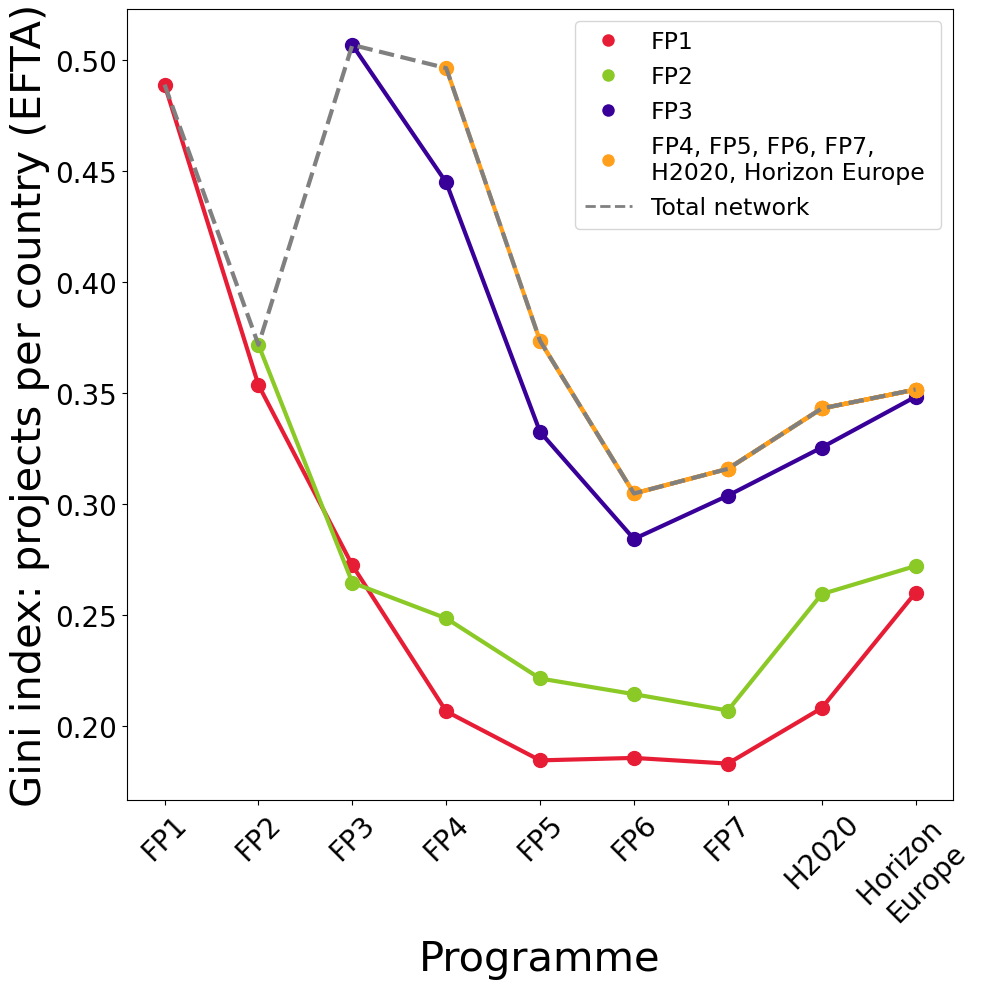

In [30]:
# gini index -> for EFTA countries , but considering the total number of projects, where also other countries (extra EFTA) are involved together whit the EFTA ones

# output dir for gini index plots
output_dir = analysis_dir / 'gini'
# population per year file
pop_year_file = data_dir / 'population per year.csv'


# DECOUPLED

# set variables
efta_org_list = []
country_col = 'country'
proj_per_capita_col = 'proj per capita'
count_proj_col = 'count_proj'
years_start = ['1985', '1989', '1992', '1996', '2000', '2004', '2010', '2017', '2023']
years = ['1985', '1989', '1992', '1996', '2000', '2004', '2010', '2017', '2023']
years += years_start[1:]
years += years_start[2:]
years += years_start[3:]
years += years_start[4:]
years += years_start[5:]
years += years_start[6:]
years += years_start[7:]
years += years_start[8:]
years += years_start[9:]

df_gini = pd.DataFrame(columns=[1, 2, 3, 4, 5, 6, 7, 8, 9], index=[0, 1, 2, 3, 4, 5, 6, 7, 8])
df_gini_capita = pd.DataFrame(columns=[1, 2, 3, 4, 5, 6, 7, 8, 9], index=[0, 1, 2, 3, 4, 5, 6, 7, 8])

# keep only efta countries
for i in range(len(os.listdir(analysis_dir / 'proj_per_country' / 'subsets'))):
    for y in range(i, 9):
        file = str(i+1) + '_' + str(y+1) + '.csv'
        df = pd.read_csv(analysis_dir / 'proj_per_country' / 'subsets' / file)
        efta_org_list += [df]

# divide per population -> # projects per capita per nation
pop = pd.read_csv(pop_year_file)
pop = pop.rename(columns={'Alpha-2 code': country_col})
pop[country_col] = pop[country_col].map(lambda x: x.lower())


# merge projects per country df and population and calculate projects per capita
distr_pop_list = []
print(len(efta_org_list))
for i in range(len(efta_org_list)):
    distr_pop = pd.merge(efta_org_list[i], pop, on=country_col, how='left')
    distr_pop[proj_per_capita_col] = distr_pop[count_proj_col] / distr_pop[years[i]]
    distr_pop_list += [distr_pop]


# compute gini index

gini_proj_country = []
gini_proj_country_capita = []

for i in range(len(efta_org_list)):
    gini_df = distr_pop_list[i]
    gini_proj_country += [gini_index(list(gini_df[count_proj_col]))]
    gini_proj_country_capita += [gini_index(list(gini_df[proj_per_capita_col]))]

start = 0
for i in range(9):
    end = start + (9 - i)
    num_zero_add = 9-(9-i)
    if num_zero_add > 0:
        zero_add = [0]*num_zero_add
    else:
        zero_add = []
    row_proj_country_capita = zero_add + gini_proj_country_capita[start:end]
    df_gini_capita.loc[i] = row_proj_country_capita
    row_proj_country = zero_add + gini_proj_country[start:end]
    df_gini.loc[i] = row_proj_country
    start = end

# programmes
prog = ['FP1', 'FP2', 'FP3', 'FP4', 'FP5', 'FP6', 'FP7', 'H2020', 'Horizon \nEurope']
prog_legend = ['FP1', 'FP2', 'FP3', 'FP4, FP5, FP6, FP7, \nH2020, Horizon Europe ']

# colors palette
#palette = ['#ff595e', '#8ac926', '#ecbcfd', '#ffca3a', '#8ecae6', '#f77f00', '#52b69a', '#390099']
palette = ['#e71d36', '#8ac926', '#390099', '#ff9f1c', '#ff9f1c', '#ff9f1c', '#ff9f1c', '#ff9f1c', '#ff9f1c']

# dict_colors for legend
dict_colors = {}
for i in range(len(prog_legend)):
    dict_colors[prog_legend[i]] = palette[i]
dict_colors['Total network'] = 'grey' #'#1f77b4'

fig,ax = plt.subplots(figsize=(fig_size_x, fig_size_y))
for i in range(len(df_gini_capita)):
    ax.plot(prog[i:], df_gini_capita.iloc[i, i:], '-o', color=palette[i], linewidth=3, markersize=10)

ax.set_xlabel('Programme', fontsize=label_size)
ax.set_ylabel('Gini index: projects per country (EFTA)', fontsize=label_size)
ax.tick_params(axis='x', labelsize=tick_size, labelrotation=45)
ax.tick_params(axis='y', labelsize=tick_size)



# TOTAL

# output dir for gini index plots
output_dir = analysis_dir / 'gini'
# population per year file
pop_year_file = data_dir / 'population per year.csv'

# set variables
efta_org_list = []
country_col = 'country'
proj_per_capita_col = 'proj per capita'
count_proj_col = 'count_proj'
years = ['1985', '1989', '1992', '1996', '2000', '2004', '2010', '2017', '2023']

# keep only efta countries
for i in range(9):
    proj_country_df = org_list_grouped[i]
    efta_org_list += [proj_country_df[proj_country_df[country_col].isin(efta_countries)]]

# divide per population -> # projects per capita per nation
pop = pd.read_csv(pop_year_file)
pop = pop.rename(columns={'Alpha-2 code': country_col})
pop[country_col] = pop[country_col].map(lambda x: x.lower())


# merge projects per country df and population and calculate projects per capita
distr_pop_list = []

for i in range(9):
    distr_pop = pd.merge(efta_org_list[i], pop, on=country_col, how='left')
    distr_pop[proj_per_capita_col] = distr_pop[count_proj_col] / distr_pop[years[i]]
    distr_pop_list += [distr_pop]



# compute gini index

gini_proj_country = []
gini_proj_country_capita = []

for i in range(9):
    gini_df = distr_pop_list[i]
    gini_proj_country += [gini_index(list(gini_df[count_proj_col]))]
    gini_proj_country_capita += [gini_index(list(gini_df[proj_per_capita_col]))]


# programmes
prog = ['FP1', 'FP2', 'FP3', 'FP4', 'FP5', 'FP6', 'FP7', 'H2020', 'Horizon \nEurope']


# plot gini proj per country per capita
# Replace the last handle with a dashed-line handle instead of a dot
last_key = list(dict_colors.keys())[-1]
ax.plot(prog, gini_proj_country_capita, linestyle='--', linewidth=3, color=dict_colors[last_key])
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=col, markerfacecolor=dict_colors[col], markersize=10) for col in dict_colors.keys()]

print(dict_colors)
print(last_key)
print(dict_colors[last_key])
legend_handles[-1] = plt.Line2D([0], [0],
                                color=dict_colors[last_key],
                                linestyle='--',
                                linewidth=2,
                                label=last_key)
ax.legend(handles=legend_handles, fontsize=legend_size) # 

plt.tight_layout()

fig.savefig(output_dir / 'decoupled_tot_gini_proj_capita_country_EFTA_BIG.png')

## Integration - segregation

##### Variables

In [24]:
# variables figure

fig_size_x = 10
fig_size_y = 10

label_size = 30

tick_size = 20

legend_size = 17

##### Total + decoupled

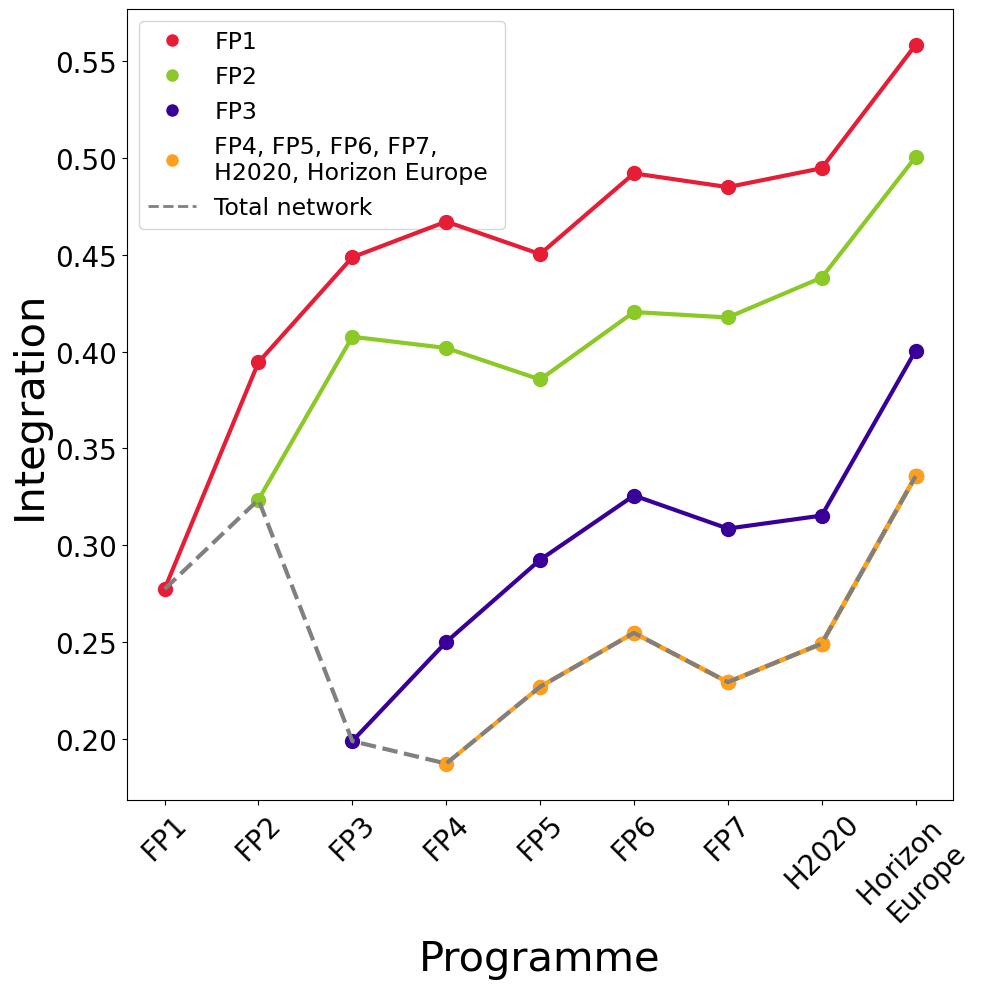

In [32]:
# integration on total networks over time

dir_int_segr = analysis_dir / 'integration segregation/'

# programmes
prog = ['FP1', 'FP2', 'FP3', 'FP4', 'FP5', 'FP6', 'FP7', 'H2020', 'Horizon \nEurope']
prog_legend = ['FP1', 'FP2', 'FP3', 'FP4, FP5, FP6, FP7, \nH2020, Horizon Europe ']
# colors palette
palette = ['#e71d36', '#8ac926', '#ff9f1c', '#390099', '#390099', '#390099', '#390099', '#390099', '#390099']
palette = ['#390099', '#8ac926', '#ff9f1c', '#e71d36', '#e71d36', '#e71d36', '#e71d36', '#e71d36', '#e71d36']
palette = ['#e71d36', '#8ac926', '#390099', '#ff9f1c', '#ff9f1c', '#ff9f1c', '#ff9f1c', '#ff9f1c', '#ff9f1c']
# dict_colors for legend
dict_colors = {}
for i in range(len(prog_legend)):
    dict_colors[prog_legend[i]] = palette[i]
dict_colors['Total network'] = 'grey' #'#1f77b4'

# integration
int_df_tot = pd.read_csv(dir_int_segr / 'integration_tot_normalized.csv')
int_df_decoupled = pd.read_csv(dir_int_segr / 'integration_time_nromalized.csv')

fig,ax = plt.subplots(figsize=(fig_size_x, fig_size_y))

for i in range(len(int_df_decoupled)):
    ax.plot(prog[i:], int_df_decoupled.loc[i][1:][i:], '-o', color=palette[i], linewidth=3, markersize=10, zorder=3)


# Replace the last handle with a dashed-line handle instead of a dot
last_key = list(dict_colors.keys())[-1]
ax.plot(prog, int_df_tot.loc[0], linestyle='--', linewidth=3, color=dict_colors[last_key], zorder=3)

'''ax.set_xlabel('Programme', fontsize=label_size)
ax.set_ylabel('Integration', fontsize=label_size)
ax.tick_params(axis='x', labelsize=tick_size)
ax.tick_params(axis='y', labelsize=tick_size)'''
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=col, markerfacecolor=dict_colors[col], markersize=10) for col in dict_colors.keys()]

legend_handles[-1] = plt.Line2D([0], [0],
                                color=dict_colors[last_key],
                                linestyle='--',
                                linewidth=2,
                                label=last_key)
legend = ax.legend(handles=legend_handles, fontsize=legend_size) # 
legend.set_zorder(0)

ax.set_xlabel('Programme', fontsize=label_size)
ax.set_ylabel('Integration', fontsize=label_size)
ax.tick_params(axis='x', labelsize=tick_size, labelrotation=45)
ax.tick_params(axis='y', labelsize=tick_size)

plt.tight_layout()

fig.savefig(dir_int_segr / 'integration_time_tot_normalized_BIG.png')


## Network map

In [27]:
# create figure

fig_x = 10
fig_y = 10

map_type = 'europe' # 'world

plt.figure(figsize = (fig_x,fig_y))


if map_type == 'world':
    m = Basemap(
        width=15500000, height=15000000, 
        resolution='l',projection='laea',\
        lat_0=35, lon_0=11
        )


elif map_type == 'europe':

    m = Basemap(
                width=4300000, height=4250000,
                resolution='l',projection='laea',\
                lat_0=53, lon_0=11
                )

<Figure size 1000x1000 with 0 Axes>

In [29]:
# set points position (lat/lon of nodes to plot on the map)

# path to file containing lat and lon
lat_lon_file = data_dir / 'lat_lon.csv'
# nodes column
node_column = 'source iso 2'
# lat column
lat_col = 'lat_source'
# lon column
lon_col = 'lon_source'

# read lat lon df
lat_lon_df = pd.read_csv(lat_lon_file)
# if needed, lower case, depending on format of 
lat_lon_df[node_column] = lat_lon_df[node_column].map(lambda x: x.lower()) #.fillna('NA')

# create positions of elements
mx, my = m(lat_lon_df[lon_col].values, lat_lon_df[lat_col].values)
lon_mer = []
lat_mer = []
pos = {}
for count, elem in enumerate (lat_lon_df[node_column]):
    pos[elem] = (mx[count], my[count])

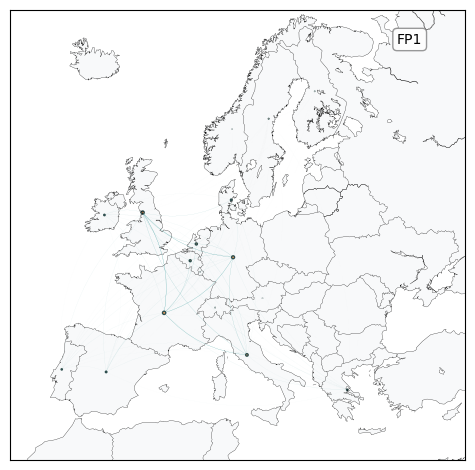

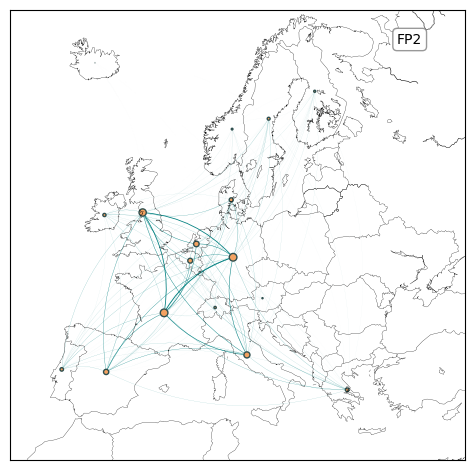

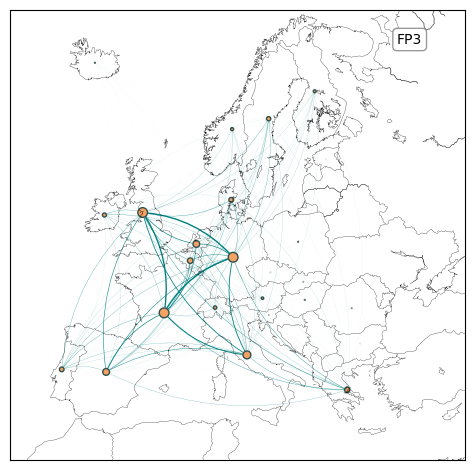

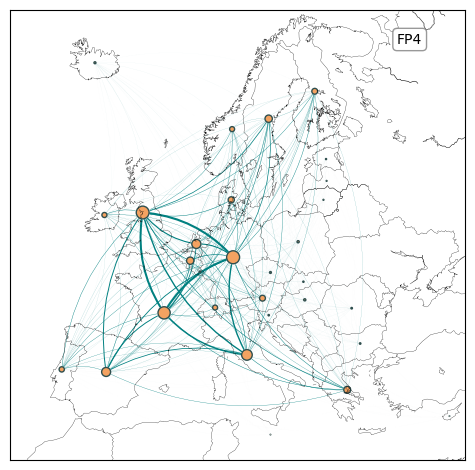

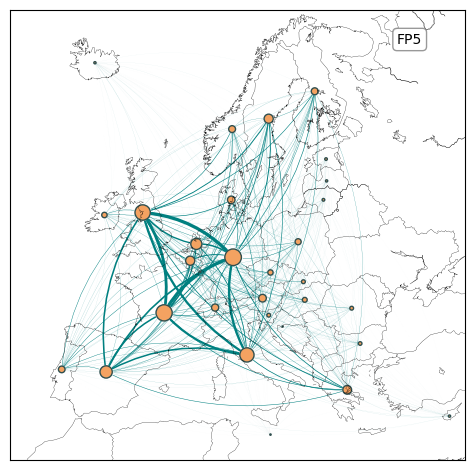

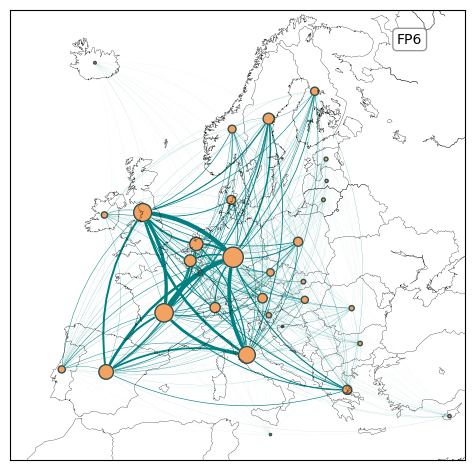

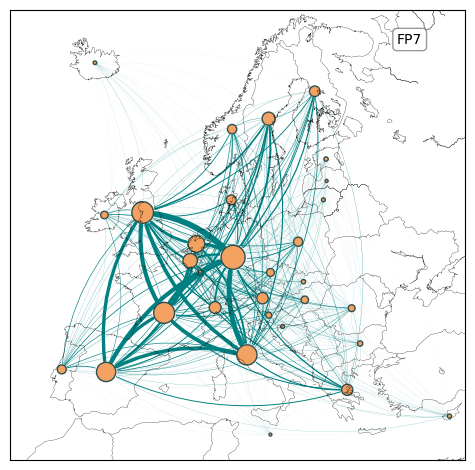

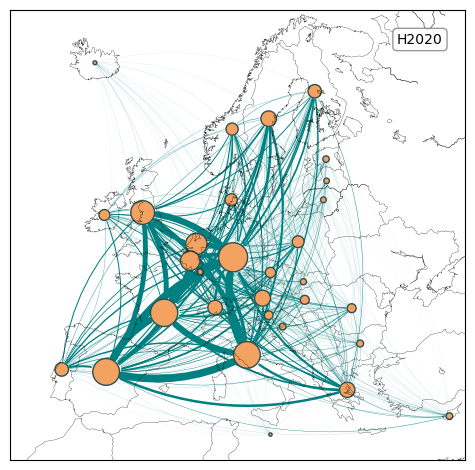

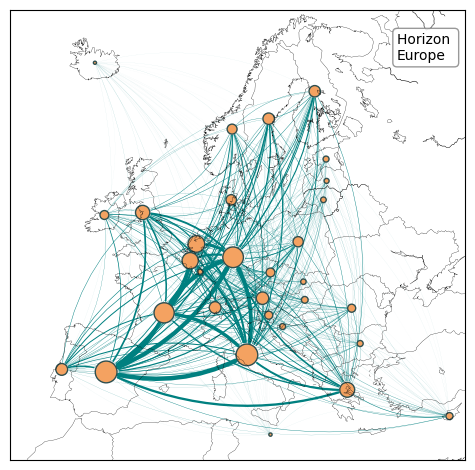

In [30]:
m.fillcontinents(color='#f8f9fa')

#input_df_dir = 'participants/community measures/coord no self/df/'

input_dir = network_dir #'network efta countries/nx graph/without self-loops/'
degree_dir = analysis_dir / 'degree no self-loops'
output_dir = network_edgelist_dir / 'maps'

# label to show in the map
labels = ['FP1', 'FP2', 'FP3', 'FP4', 'FP5', 'FP6' , 'FP7', 'H2020', 'Horizon \nEurope']

i = 0

for i in range(9):

    n = str(i+1)

    network_file = 'network_' + n + '.graphml'
    g = nx.read_graphml(input_dir / network_file)

    #g.remove_edges_from(nx.selfloop_edges(g))
    
    weights = [g[u][v]['weight'] for u, v in g.edges()]
    degree_file = 'degree_' + n + '.csv'
    degree_df = pd.read_csv(degree_dir / degree_file)

    nx.draw_networkx_nodes(G = g, pos = pos, node_color = '#f4a261', alpha = 1, node_size = degree_df['degree']/700, edgecolors='darkslategray')
    nx.draw_networkx_edges(G = g, pos = pos, edge_color='teal', width=np.array(weights).astype(float)/7000, alpha=1, arrows=True, arrowstyle='-', connectionstyle = 'arc3,rad=0.2', min_source_margin=0, min_target_margin=0, node_size = degree_df['degree']/500)

    m.drawcountries(linewidth = 0.2)

    m.drawstates(linewidth = 0.2)

    m.drawcoastlines(linewidth=0.2)


    # optional -> to make label on the map
    plt.text(
        0.85, 0.95,  # x, y in axis coordinates
        labels[i],
        transform=plt.gca().transAxes,  # coordinates relative to axes
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
    )

    plt.tight_layout()

    output_file = "europe_efta_" + n + '.png'
    #plt.savefig(output_dir / output_file)
    
    plt.show()